# Image Similarity in Machine Learning



Image similarity is the task of measuring how visually or semantically similar two images are.

The definition of "similar" depends on the application:

| Type                    | What is compared?                             | Example                   |
| ----------------------- | --------------------------------------------- | ------------------------- |
| Pixel Similarity        | Exact pixel values                            | Detect duplicate images   |
| Structural Similarity   | Image structure (brightness, contrast, edges) | Image compression quality |
| Feature Similarity      | Local features like corners and keypoints     | Panorama stitching        |
| Deep Feature Similarity | Semantic content learned by CNNs              | Reverse image search      |
| Embedding Similarity    | Vector representation from neural networks    | Face recognition          |


| Method               | Complexity | Robust to Rotation | Robust to Scale | Robust to Lighting | Semantic Understanding |
| -------------------- | ---------- | ------------------ | --------------- | ------------------ | ---------------------- |
| MSE                  | ⭐          | ❌                  | ❌               | ❌                  | ❌                      |
| PSNR                 | ⭐          | ❌                  | ❌               | ❌                  | ❌                      |
| Histogram Comparison | ⭐⭐         | ✅                  | ✅               | ⚠️                 | ❌                      |
| SSIM                 | ⭐⭐         | ❌                  | ❌               | ✅                  | ❌                      |
| ORB/SIFT             | ⭐⭐⭐        | ✅                  | ✅               | ✅                  | ❌                      |
| CNN Embeddings       | ⭐⭐⭐⭐       | ✅                  | ✅               | ✅                  | ✅                      |
| CLIP Embeddings      | ⭐⭐⭐⭐⭐      | ✅                  | ✅               | ✅                  | ⭐⭐⭐⭐⭐                  |


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from transformers import CLIPModel, CLIPProcessor

## 1. Mean Squared Error (MSE)
 - Lower is better. ( Compares images pixel-by-pixel. )
 - MSE is very small → images are almost identical.

In [15]:
img1 = cv2.imread("data/floppa.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = np.clip(img1 * 1.1, 0, 255).astype(np.uint8)

mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)

print(f'MSE: {mse}')

150.61286643180236


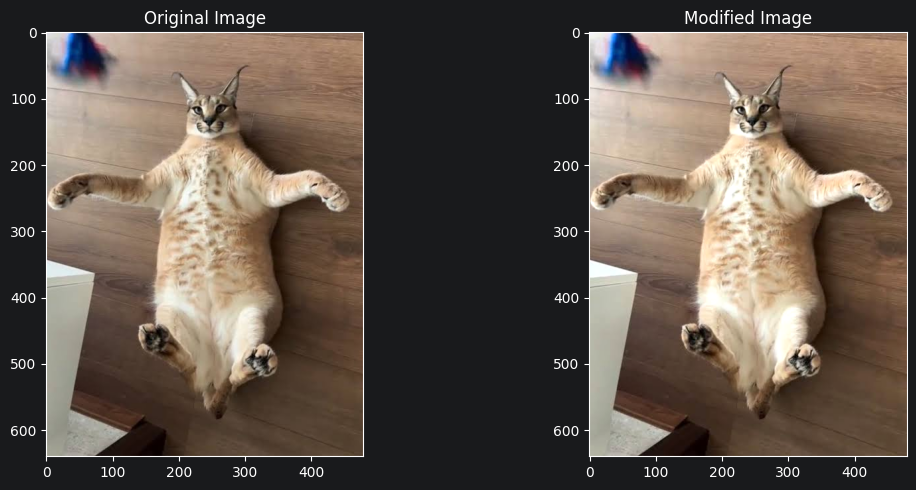

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img1)
ax1.set_title("Original Image")
ax2.imshow(img2)
ax2.set_title("Modified Image")
plt.tight_layout()
plt.show()

## 2. Structural Similarity Index (SSIM)

Instead of comparing pixels directly, SSIM compares:
 - luminance
 - contrast
 - structure

 Score:

- 1.0 = identical
- 0.0 = completely different

In [20]:
img1 = cv2.imread("data/floppa.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = np.clip(img1 * 1.1, 0, 255).astype(np.uint8)


score, diff = structural_similarity(
    img1, img2,
    full=True,
    channel_axis=2,  # RGB has 3 channels at axis 2
    win_size=5       # Use smaller window size
)

print(f'Identity: {score * 100:.2f}%')

Identity: 99.11%


## 3. Histogram Comparison

> Instead of pixels, compare color distributions.

In [21]:
img1 = cv2.imread("data/floppa.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = np.clip(img1 * 1.1, 0, 255).astype(np.uint8)

hist1 = cv2.calcHist([img1],[0],None,[256],[0,256])
hist2 = cv2.calcHist([img2],[0],None,[256],[0,256])

score = cv2.compareHist(
    hist1,
    hist2,
    cv2.HISTCMP_CORREL
)

print(f'Histogram Similarity: {score * 100:.2f}%')

Histogram Similarity: 51.92%


## 4. ORB Feature Matching

Instead of comparing pixels, ORB detects:

- corners
- edges
- texture

Even if images are:

- rotated
- scaled
- slightly noisy

ORB still works.

In [22]:
img1 = cv2.imread("data/floppa.jpg")
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = np.clip(img1 * 1.1, 0, 255).astype(np.uint8)

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.match(des1, des2)

print(f'Number of ORB matches: {len(matches)}')
# More matches = more similar.

Number of ORB matches: 500


## 5. Deep Learning Embeddings (TensorFlow)

> This is the modern approach. <br/>
> Instead of comparing images directly: IMAGE -> CNN -> VECTOR (EMBEDDING) -> Cosine Similarity


In [6]:
# ---------------------------------------------------
# Load pretrained MobileNetV2
# ---------------------------------------------------

model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

# ---------------------------------------------------
# Function to convert image into embedding vector
# ---------------------------------------------------

def get_embedding(image_path):

    # Load image
    img = image.load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert to numpy
    x = image.img_to_array(img)

    # Add batch dimension
    x = np.expand_dims(x, axis=0)

    # Normalize
    x = preprocess_input(x)

    # Extract embedding
    embedding = model.predict(x, verbose=0)

    return embedding

# ---------------------------------------------------
# Compare two images
# ---------------------------------------------------

embedding1 = get_embedding("data/cat.png")
embedding2 = get_embedding("data/cat0.png")

similarity = cosine_similarity(
    embedding1,
    embedding2
)[0][0]

print(f"Similarity Score: {similarity:.4f}")

# ---------------------------------------------------
# Interpretation
# ---------------------------------------------------

if similarity > 0.95:
    print("Nearly identical")

elif similarity > 0.80:
    print("Very similar")

elif similarity > 0.60:
    print("Somewhat similar")

else:
    print("Different images")

C:\Users\username\AppData\Local\Temp\ipykernel_12444\1455704072.py:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(


Similarity Score: 0.7972
Somewhat similar


## CLIP (Contrastive Language-Image Pretraining)
> is one of the most powerful models for image similarity because it learns a shared embedding space for images and text.

Unlike MobileNet or ResNet, which are trained only for image classification, CLIP is trained on hundreds of millions of image-text pairs, allowing it to capture semantic meaning.

In [15]:
# Load model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    # Process only image (don't include text)
    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():
        # Use vision_model to get only image embeddings
        image_features = model.vision_model(**inputs)
        # Extract pooled output
        features = image_features.pooler_output

    # Normalize
    features = F.normalize(features, p=2, dim=-1)

    return features.cpu().numpy()

# Compare two images
embedding1 = get_embedding("data/cat.png")
embedding2 = get_embedding("data/cat0.png")

score = cosine_similarity(embedding1, embedding2)[0][0]
print(f"Similarity = {score:.4f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Similarity = 0.9018


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]